## Population Map of Georgia (US State)
* Shape file (how we know what the map looks like): come from the US Census Bureau TIGER/LINE 2023 county boundaries
* Population: ACS 5-year, table B01003 (Total Population Estimates)

In [21]:
# Standard Dependencies
import io, zipfile, tempfile, os, requests # IO - reaading/writing data, zipfile - zips data, tempfile - creates temporary files in memory, os - allows interaction with operating system, requests - handles API calls
import matplotlib.pyplot as plt # How we will create the figures

# Data Handling Dependencies
import geopandas as gpd # Tells python how to deal with geographic data
import pandas as pd # Allows us to deal with generic datasets (this is what we do most often use in empiric work)

# URLS and other script level variables
TIGER_URL = (
    "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
)
ACS_URL = (
    "https://api.census.gov/data/2023/acs/acs5"
    "?get=NAME,B01003_001E" # Get just the Total Population variable (B01003_001E)
    "&for=county:*" # Get All counties
    "&in=state:13"  # GA state code is 13
)

In [22]:
# Extract the Shapefile from the US Census TIGER/LINE data
r = requests.get(TIGER_URL)
r.raise_for_status()
with tempfile.TemporaryDirectory() as tmp: 
    zip_path = os.path.join(tmp, "counties.zip")
    with open(zip_path, "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(tmp)
    # The shapefile lives directly in the tmp after extraction, so we can read it directly
    shp_file = [f for f in os.listdir(tmp) if f.endswith(".shp")][0]
    counties = gpd.read_file(os.path.join(tmp, shp_file))

ga = counties[(counties['STATEFP']=='13') | (counties['STATEFP']=='13')].copy() # Subset to just GA counties
print(f"Loaded {len(ga)} Georgia counties")

Loaded 159 Georgia counties


In [23]:
# Extract the data from the 5 year ACS
r = requests.get(ACS_URL)
r.raise_for_status()
data = r.json()
"""
The data is structured like:
[['COUNTY NAME, STATE', 'POPULATION','STATE FIPS', 'COUNTY FIPS']] 

So we want to make a dataframe where we map the COUNTY FIPS to the POPULATION (i.e. column column 4 with column 2)
"""
print(data)
pop_df = pd.DataFrame(data[1:], columns=data[0]) # Reorient to be long withi NAME, POPULATION (B01003_001E), STATE FIPS, and COUNTY FIPS as columns

pop_df.columns = ['COUNTY_NAME','POPULATION','STATE_FIPS','COUNTY_FIPS']
pop_df['GEOID'] = pop_df['STATE_FIPS'] + pop_df['COUNTY_FIPS'] # The Shapefile expects a 'GEOID' column which is the concatenation of state and column fips (NOTE: FIPS -- FEDERAL INFORMATION PROCESSING STANDARD, they are not always just states and counties, but also some industries have fips codes... )

# Make sure the 'type' is correct. If left untreated, population will be a string not a number (this is done by all API calls).
pop_df['POPULATION'] = pop_df['POPULATION'].astype(int)

# If curious we can take a look physically at the data we just pulled and make sure it looks right
print(f"Data Example: \n {pop_df.head()} \n ")
print(f"Population Range for Georgia: {pop_df['POPULATION'].min():,} to {pop_df['POPULATION'].max():,}")

# This is a standard that I do, moving forward we only want to plot a single thing with the map. If we merge inthe whole data we waste precious compute time and resources. I always create
# an object called 'doi' (data of interest) which is the BARE MINIMUM object to combine with the shape file. In this case, we want the GEOID and the POPULATION. 
doi = pop_df[['GEOID','POPULATION']].copy()

[['NAME', 'B01003_001E', 'state', 'county'], ['Appling County, Georgia', '18426', '13', '001'], ['Atkinson County, Georgia', '8261', '13', '003'], ['Bacon County, Georgia', '11129', '13', '005'], ['Baker County, Georgia', '2830', '13', '007'], ['Baldwin County, Georgia', '43669', '13', '009'], ['Banks County, Georgia', '18757', '13', '011'], ['Barrow County, Georgia', '86982', '13', '013'], ['Bartow County, Georgia', '111153', '13', '015'], ['Ben Hill County, Georgia', '17138', '13', '017'], ['Berrien County, Georgia', '18257', '13', '019'], ['Bibb County, Georgia', '156543', '13', '021'], ['Bleckley County, Georgia', '12414', '13', '023'], ['Brantley County, Georgia', '18171', '13', '025'], ['Brooks County, Georgia', '16285', '13', '027'], ['Bryan County, Georgia', '46681', '13', '029'], ['Bulloch County, Georgia', '81372', '13', '031'], ['Burke County, Georgia', '24427', '13', '033'], ['Butts County, Georgia', '26074', '13', '035'], ['Calhoun County, Georgia', '5528', '13', '037'], [

### Even if the API Doesnt work, all you need is the State_ID, County ID (GEOID = concatenate State_id and county_id), and the variable of interest. 
Save as "doi" 


In [ ]:
#e.g.
# doi = pd.read_csv('my_county_level_data.csv')[['GEOID','MY_VARIABLE']].copy() # This is how I would do it if I had a csv file instead of an API call


<function matplotlib.pyplot.show(close=None, block=None)>

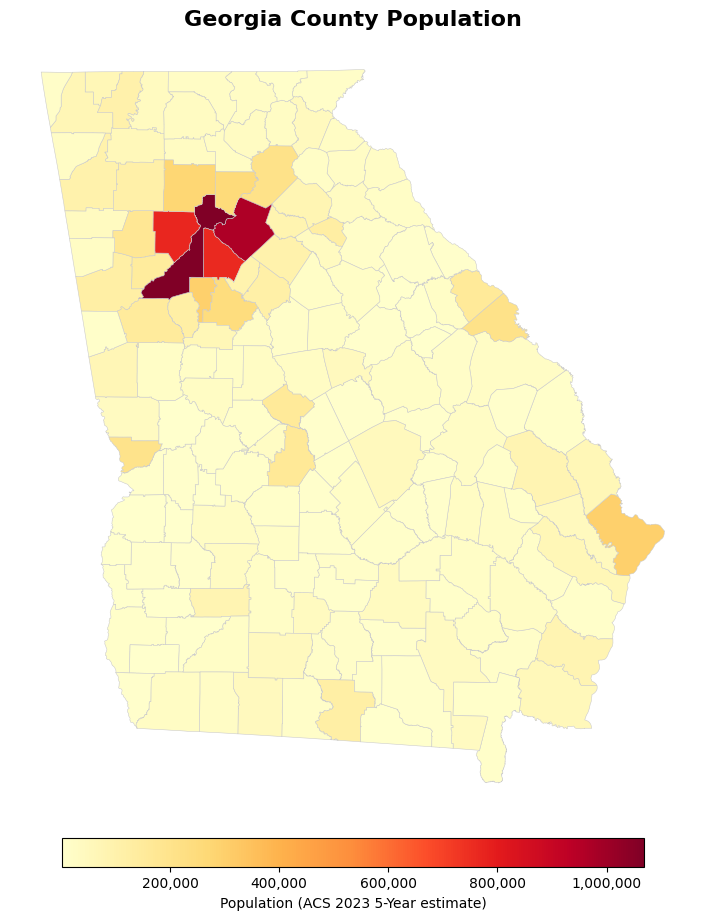

In [24]:
# Merge the Data of Interest with the Shape file
from matplotlib import ticker
ga = ga.merge(doi, on='GEOID', how='left')


# Create the map!
fig, ax = plt.subplots(1,1,figsize=(10,10))
ga.plot(
    column='POPULATION',
    cmap="YlOrRd", 
    linewidth=0.4,
    edgecolor='0.8',
    legend=True,
    legend_kwds={
        "label":"Population (ACS 2023 5-Year estimate)",
        "orientation":"horizontal",
        "shrink":0.6,
        "pad":0.02,
        "format":ticker.FuncFormatter(lambda x, pos: f"{int(x):,.0f}") # Format the legend labels with commas
    },
    ax=ax,
)

ax.set_title("Georgia County Population", fontsize=16, fontweight="bold")
ax.axis('off')
plt.tight_layout()
plt.show



There is your map! Now you've learned the basics. Now, one thing that is worthy of noting. In GA's case, as with many other states, the relative size of the metro area makes the rest of the state appear more homogenous than it is, in reality. 

One way we can approach this is by using a `normalizer' 

When we normalize, we aren't changing the underlying data, but we are rather changing the color spectrum, sliding the locations of the population counts around to observe greater variation in smaller areas. 

If you're mathematically inclined, the way I would think about this is that the color map is a function. Let's talk about the example above. This is a linear color map such that for county $i$, with population $P_i$, the share of the total 
state of Georgia population in $i$ is given by: $S_i = \frac{P_i}{\sum_{j\in GA} P_j} \in [0,1]$. Each county lies between between 0% of the entire state of GA population and 100% of the entire population, this is true. So the linear color map $c$, takes these shares $S_i \in [0,1]$ as inputs, and returns an RGB value. More straightforward, 
$c: [0,1] \rightarrow$ RGB. 

There is something off with this, however. The maximum values for the countires values, $[0,1]$ aren't really pragmatic here because no county isi going to be exactly $0\%$ of the state population, nor is any one going to be $100\%$ of the state population. So instead, we can do an initial normalization by the minimum and maximum value we have. 
Define the normalizer $N$ as $N : [\text{vmin}, \text{vmax}] \rightarrow [0,1]$. Then the normalized color map can be defined by the function $c(N(x)) : [\text{vmin}, \text{vmax}] \rightarrow$ RGB. 

This gets us what we have above, a linear, normalized color map (it is why we can get colors close to the maximum and close to the minimum, without this linear normalization we would have a minimum of 0 on the legend and a maximum of 11 million.)

If we want to see more detail at the lower level, however, we can apply a non-linear transformer. There are several different types to use: 
---
* Linear (DEFAULT): $N(x) = \frac{x-x_{min}}{x_{max} - x_{min}}$
* LogNormal (``LogNorm'') : $N(x) = \frac{\log x- \log x_{min}}{\log x_{max}-log x{min}}$  
* Power $\gamma$ (``PowerNorm(gamma)''): $N(x) = \left( \frac{x-x_{min}}{x_{max} - x_{min}} \right)^{\gamma}$
* Symmetric Log (``SymLogNorm(linthreshold)''): Linear near 0, log in tails
* Arbitrary breakpoint (BoundaryNorm(bounds)): Discrete bins you define in a list [100, 200, 300, etc.. ]

<function matplotlib.pyplot.show(close=None, block=None)>

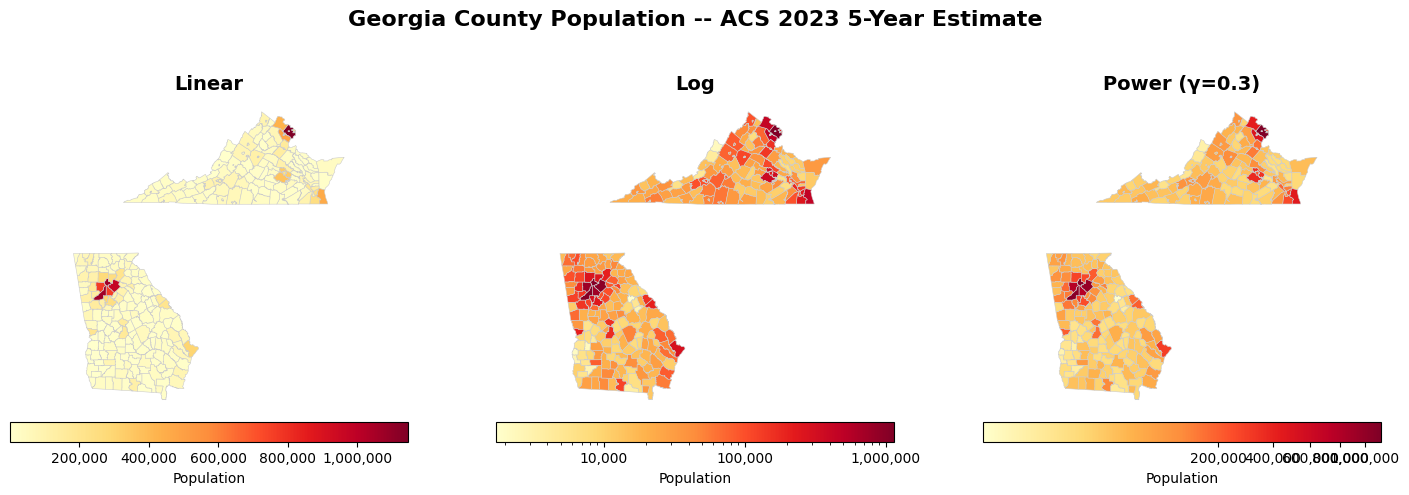

In [20]:
# Try some different Normalizations: 
from matplotlib import axes
from matplotlib.colors import LogNorm, PowerNorm, Normalize

vmin, vmax = ga['POPULATION'].min(), ga['POPULATION'].max()
# I personall don't recommend Symmetric Log or Arbitrary breakpoints (unless you have something like an explicit policy intervention you want to map). They are kind of arbitrary and can be misleading 
# Here is a quick comparison 

norms = [
    ("Linear", Normalize(vmin=vmin, vmax=vmax)),
    ("Log", LogNorm(vmin=vmin, vmax=vmax)),
    ("Power (γ=0.3)", PowerNorm(gamma=0.3, vmin=vmin, vmax=vmax)),
]

# Three side by side figures (compare to the single figure above) 
fig, axes = plt.subplots(1,3,figsize=(15,5))
for ax, (label,norm) in zip(axes, norms):
    ga.plot(
        column='POPULATION',
        cmap="YlOrRd", 
        norm = norm, 
        linewidth=0.4,
        edgecolor='0.8',
        legend=True,
        legend_kwds={
            "label":"Population",
            "orientation":"horizontal",
            "shrink":0.8,
            "pad":0.02,
            "format":ticker.FuncFormatter(lambda x, pos: f"{int(x):,.0f}") # Format the legend labels with commas
        },
        ax=ax,
    )
    ax.set_title(label, fontsize=14, fontweight="bold")
    ax.axis('off')
fig.suptitle(
    "Georgia County Population -- ACS 2023 5-Year Estimate",
    fontsize=16, fontweight="bold",
    y=0.97
)

plt.tight_layout(rect=[0,0,1,0.94])
plt.show



As you can see, the three figures Look reasonable, LogNorming gives a lot more variation, but looks almost misrepresentative. Gamma Does a better job at preserving the importance, I think! 
